# 08 — Design Matrices and Model Prediction

## Purpose

In the previous notebooks, we saw least squares from two useful angles:

- as a way to choose a line that fits points well
- as a projection idea, where a target vector is approximated using vectors we are allowed to combine

This notebook changes the question.

We are **not** trying to choose the best-fitting line here. We are assuming a model has already been supplied. That model might have been fitted earlier, chosen by hand, loaded from a file, or handed to us by someone else.

The question for this notebook is:

> Given a supplied model, how do we arrange several values so the model can produce a batch of predictions?

The main idea is:

> A supplied model can make many predictions at once when we arrange the values it needs into a **design matrix**.

By the end, we want this expression to feel natural:

$$
\hat{y} = X\beta
$$

where:

- $X$ is the **design matrix**: the model-ready table of terms used for prediction
- $\beta$ is the vector of **model parameters**: the numbers the supplied model uses
- $\hat{y}$ is the vector of **predictions**

This is the bridge from a familiar line equation:

$$
\hat{y} = mx + c
$$

to the compact matrix form used throughout machine learning:

$$
\hat{y} = X\beta
$$


## Why this notebook exists

So far, we have mostly worked with small vectors and matrices as mathematical objects.

Machine learning uses the same objects, but gives them practical jobs.

In this notebook, the practical job is **prediction**, not model fitting.

| Maths object | Prediction-time interpretation |
|---|---|
| vector | one list of values, such as all predictions |
| matrix | a table of model-ready terms |
| row of a design matrix | one item we want a prediction for |
| column of a design matrix | one term consumed by the model |
| matrix multiplication | many row-by-row prediction calculations done at once |
| parameter vector | the supplied model numbers used in those calculations |

A design matrix is therefore not just "the input data" in a loose sense.

It is more precise to think of it as:

> the table of values and model terms that the supplied model consumes to make predictions.

That distinction matters because $X$ may contain more than the raw feature values. For example, in this notebook it will contain a column of ones so the model can include an intercept.

The observed target values $y$ are separate. They are not part of $X$. We only use them later to check or score the predictions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## A tiny set of values to score

We'll use a small toy example so the shapes and calculations stay visible.

Imagine $x$ is a value we want to feed into a supplied straight-line model.

We will also keep observed $y$ values nearby, but only so that we can compare predictions with reality later.

In ML language:

- $x$ is a **feature value** or **predictor value**
- $y$ is the **observed target**
- $\hat{y}$ is the **prediction** made by the supplied model

For now, there is only one feature. Later, the same structure will work with many features.


In [2]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

x, y


(array([1., 2., 3., 4., 5.]), array([2.2, 2.8, 3.6, 4.5, 5.1]))

For now, do not worry about finding the best line.

We'll use a candidate model with a supplied slope and intercept:

$$
\hat{y} = mx + c
$$

where:

- $m$ is the slope
- $c$ is the intercept
- $\hat{y}$ means "predicted y"

You can imagine these values were found in an earlier notebook, fitted by another system, or simply chosen for demonstration.


In [3]:
m = 0.75
c = 1.3

y_hat_direct = m * x + c
y_hat_direct


array([2.05, 2.8 , 3.55, 4.3 , 5.05])

## One prediction at a time

For a single row or observation, the familiar line model is:

$$
\hat{y}_i = mx_i + c
$$

The subscript $i$ means "for row $i$" or "for observation $i$".

Very soon, we are going to put the intercept first in the parameter vector:

$$
\beta =
\begin{bmatrix}
c \\
m
\end{bmatrix}
$$

So it is useful to rewrite the same equation as:

$$
\hat{y}_i = c + mx_i
$$

Nothing has changed mathematically. We have only swapped the order of the terms so it lines up with the parameter vector we are about to build.

For the first input value, $x_1 = 1$, the prediction is:

$$
\hat{y}_1 = c + mx_1
$$


In [4]:
x_1 = x[0]

y_hat_1 = c + m * x_1

print(f"x_1 = {x_1}")
print(f"prediction = {y_hat_1}")


x_1 = 1.0
prediction = 2.05


For several values, the same calculation repeats:

$$
\hat{y}_1 = c + mx_1
$$

$$
\hat{y}_2 = c + mx_2
$$

$$
\hat{y}_3 = c + mx_3
$$

$$
\hat{y}_4 = c + mx_4
$$

$$
\hat{y}_5 = c + mx_5
$$

This kind of repeated prediction calculation is exactly what matrix multiplication is good at.


## Making the repeated calculation into a matrix calculation

We want each row to carry enough information to make one prediction.

The line equation is:

$$
\hat{y}_i = c + mx_i
$$

We can rewrite this as:

$$
\hat{y}_i = 1c + x_i m
$$

That means each row can be written as:

$$
\begin{bmatrix}
1 & x_i
\end{bmatrix}
$$

and the supplied model parameters can be written as:

$$
\beta =
\begin{bmatrix}
c \\
m
\end{bmatrix}
$$

Then one row times the parameter vector gives one prediction:

$$
\begin{bmatrix}
1 & x_i
\end{bmatrix}
\begin{bmatrix}
c \\
m
\end{bmatrix}
=
1c + x_i m
$$

The order is not magic. We could put the $x_i$ column first and the ones column second, but then $\beta$ would also need to be reordered. The important rule is:

> columns in $X$ must line up with entries in $\beta$.


## The design matrix

For all our values, the rows stack into a matrix:

$$
X =
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
1 & x_3 \\
1 & x_4 \\
1 & x_5
\end{bmatrix}
$$

This is called a **design matrix**.

The word "design" is common in statistics and machine learning. It means the matrix has been arranged into the shape required by the model.

In this simple example:

- the first column is the intercept term, represented by ones
- the second column is the feature value $x$
- the observed values $y$ are **not** inside $X$; they are what we compare the predictions against

So $X$ is not "all the training data".

For this notebook, $X$ is better understood as:

> the model-ready prediction table: one row per value to score, one column per term the supplied model expects.


In [5]:
# np.ones_like(x) creates an array of ones with the same shape as x.
# We use this for the intercept column.

intercept_column = np.ones_like(x)

# np.column_stack(...) takes one-dimensional arrays and stacks them as columns.
# Here, the first column is all ones, and the second column is x.

X = np.column_stack([intercept_column, x])

X


array([[1., 1.],
       [1., 2.],
       [1., 3.],
       [1., 4.],
       [1., 5.]])

The first column is all ones. This is not random decoration.

The column of ones lets the intercept $c$ participate in matrix multiplication.

Each row says:

$$
\begin{bmatrix}
1 & x_i
\end{bmatrix}
\begin{bmatrix}
c \\
m
\end{bmatrix}
=
1c + x_i m
$$

Without the column of ones, the model would only have the $mx_i$ part.

Another way to say it:

> the ones column is how the design matrix carries the constant part of the supplied model.


## The parameter vector

Now collect the supplied intercept and slope into one vector:

$$
\beta =
\begin{bmatrix}
c \\
m
\end{bmatrix}
$$

This vector is applied to the design matrix by matrix multiplication:

$$
X\beta
$$

The entries of $\beta$ are the model's numbers. In a fitted model, these are the numbers the learning process has chosen. In this notebook, we are taking them as already supplied.

Different fields use slightly different words for this vector:

- **parameters**
- **coefficients**
- **weights**

For this notebook, we'll mostly say **parameters** or **coefficients**.


In [6]:
beta = np.array([c, m])

beta


array([1.3 , 0.75])

## Predicting with matrix multiplication

Now the whole prediction step is:

$$
\hat{y} = X\beta
$$

This produces all predictions at once.

The model has already been supplied through $\beta$. The design matrix $X$ provides the rows and terms the model needs to consume.


In [7]:
y_hat_matrix = X @ beta

y_hat_matrix


array([2.05, 2.8 , 3.55, 4.3 , 5.05])

This should match the direct calculation:

$$
\hat{y} = mx + c
$$


In [8]:
comparison = np.column_stack([x, y_hat_direct, y_hat_matrix])

print("columns: x, direct prediction, matrix prediction")
comparison


columns: x, direct prediction, matrix prediction


array([[1.  , 2.05, 2.05],
       [2.  , 2.8 , 2.8 ],
       [3.  , 3.55, 3.55],
       [4.  , 4.3 , 4.3 ],
       [5.  , 5.05, 5.05]])

In [9]:
np.allclose(y_hat_direct, y_hat_matrix)


True

The direct calculation and the matrix calculation are the same.

The point of the matrix version is not that it changes the model.

The point is that it gives us a clean general form:

$$
\hat{y} = X\beta
$$

That form scales naturally to:

- many rows to score
- many features or model terms
- many model parameters


## Visualising the supplied candidate model

The line below is not necessarily the best line.

It is just the line produced by the supplied parameters:

$$
\beta =
\begin{bmatrix}
c \\
m
\end{bmatrix}
$$

This keeps the notebook in prediction mode: we are using a model, not fitting one.


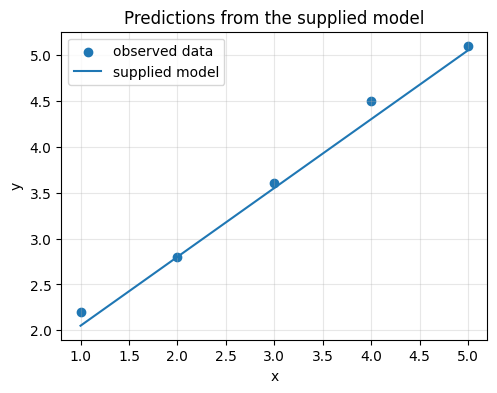

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4))

ax.scatter(x, y, label="observed data")

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + c

ax.plot(x_line, y_line, label="supplied model")

ax.set_title("Predictions from the supplied model")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


## Residuals preview

Once we have predictions, and once observed values are available, we can compare them.

A common definition of residual is:

$$
r_i = y_i - \hat{y}_i
$$

So:

- positive residual: actual value is above the prediction
- negative residual: actual value is below the prediction
- zero residual: prediction exactly matches the actual value

The full residual vector is:

$$
r = y - \hat{y}
$$

In the next plot, each residual is drawn as a vertical line segment from the model prediction up or down to the observed point.

This prepares us for loss functions in the next notebook.


In [11]:
residuals = y - y_hat_matrix

residual_table = np.column_stack([x, y, y_hat_matrix, residuals])

print("columns: x, observed y, predicted y_hat, residual")
residual_table


columns: x, observed y, predicted y_hat, residual


array([[1.  , 2.2 , 2.05, 0.15],
       [2.  , 2.8 , 2.8 , 0.  ],
       [3.  , 3.6 , 3.55, 0.05],
       [4.  , 4.5 , 4.3 , 0.2 ],
       [5.  , 5.1 , 5.05, 0.05]])

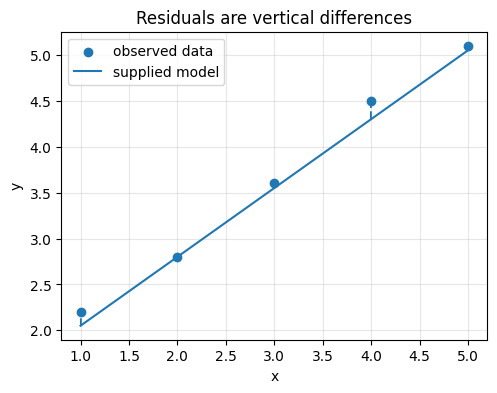

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4))

ax.scatter(x, y, label="observed data", zorder=3)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + c
ax.plot(x_line, y_line, label="supplied model", zorder=2)

# Each vertical segment shows one residual: y_i - y_hat_i.
for x_i, y_i, y_hat_i in zip(x, y, y_hat_matrix):
    ax.vlines(
        x=x_i,
        ymin=min(y_i, y_hat_i),
        ymax=max(y_i, y_hat_i),
        linestyles="--",
        linewidth=1.5,
        zorder=1,
    )

ax.set_title("Residuals are vertical differences")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


## Shape check

Before moving on, it is worth checking the shapes.

For:

$$
\hat{y} = X\beta
$$

we have:

$$
X \in \mathbb{R}^{5 \times 2}
$$

and:

$$
\beta \in \mathbb{R}^{2}
$$

so:

$$
\hat{y} \in \mathbb{R}^{5}
$$

In plain English:

- 5 rows in the design matrix: 5 values to score
- 2 columns in the design matrix: 2 model terms per row
- 2 parameters: one matching number for each column
- 5 predictions: one prediction per row

In NumPy, `beta` is stored as a one-dimensional array with shape `(2,)`. On paper, we often draw it as a column vector because that makes the matrix multiplication easier to see.


In [13]:
print(f"x shape:      {x.shape}")
print(f"X shape:      {X.shape}")
print(f"beta shape:   {beta.shape}")
print(f"y_hat shape:  {y_hat_matrix.shape}")


x shape:      (5,)
X shape:      (5, 2)
beta shape:   (2,)
y_hat shape:  (5,)


The number of columns in $X$ must match the number of entries in $\beta$.

That is the matrix multiplication rule showing up in prediction form:

$$
(5 \times 2)(2) \rightarrow (5)
$$

Or, thinking in row-by-row terms:

> each row of $X$ has two model terms, so each row needs two matching parameters.


## A small manual row check

Let's take the third row of $X$.

Because Python is zero-indexed, the third row has index `2`.


In [14]:
row_index = 2

X_row = X[row_index]
x_value = x[row_index]

manual_prediction = X_row[0] * beta[0] + X_row[1] * beta[1]
matrix_prediction = X_row @ beta

print(f"x value: {x_value}")
print(f"design matrix row: {X_row}")
print(f"manual prediction: {manual_prediction}")
print(f"row @ beta prediction: {matrix_prediction}")


x value: 3.0
design matrix row: [1. 3.]
manual prediction: 3.55
row @ beta prediction: 3.55


That one row calculation is the whole idea in miniature:

$$
\begin{bmatrix}
1 & x_i
\end{bmatrix}
\begin{bmatrix}
c \\
m
\end{bmatrix}
=
\hat{y}_i
$$

The full matrix calculation just performs the same row calculation for every row we want to score.


## Preview: more than one feature

Real machine learning datasets usually have more than one feature value per row.

For example, suppose a supplied model predicts from two features:

$$
\hat{y}_i = b_0 + b_1x_{i1} + b_2x_{i2}
$$

Here:

- $b_0$ is the intercept
- $b_1$ is the coefficient for feature 1
- $b_2$ is the coefficient for feature 2
- $x_{i1}$ is feature 1 for row $i$
- $x_{i2}$ is feature 2 for row $i$

The design matrix becomes:

$$
X =
\begin{bmatrix}
1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\
1 & x_{31} & x_{32}
\end{bmatrix}
$$

and the parameter vector becomes:

$$
\beta =
\begin{bmatrix}
b_0 \\
b_1 \\
b_2
\end{bmatrix}
$$

But the prediction equation stays the same:

$$
\hat{y} = X\beta
$$


In [15]:
# A tiny two-feature example.
# Each row is one item we want to score.
# Each column after the intercept is one feature term consumed by the model.

feature_1 = np.array([1, 2, 3], dtype=float)
feature_2 = np.array([10, 20, 30], dtype=float)

X_two_features = np.column_stack([
    np.ones_like(feature_1),
    feature_1,
    feature_2
])

beta_two_features = np.array([0.5, 2.0, -0.1])

y_hat_two_features = X_two_features @ beta_two_features

print("X:")
print(X_two_features)

print("\nbeta:")
print(beta_two_features)

print("\npredictions:")
print(y_hat_two_features)


X:
[[ 1.  1. 10.]
 [ 1.  2. 20.]
 [ 1.  3. 30.]]

beta:
[ 0.5  2.  -0.1]

predictions:
[1.5 2.5 3.5]


Check the first row manually:

$$
\hat{y}_1 = b_0 + b_1x_{11} + b_2x_{12}
$$

Using the numbers above:

$$
\hat{y}_1 = 0.5 + 2.0(1) - 0.1(10)
$$

So:

$$
\hat{y}_1 = 1.5
$$


In [16]:
manual_first_prediction = 0.5 + 2.0 * 1 - 0.1 * 10

manual_first_prediction


1.5

Again, the point is not the particular numbers.

The point is the structure:

$$
\hat{y} = X\beta
$$

This is one of the most useful shapes in machine learning, both when fitting a model and when using an already-fitted model to make predictions.

This notebook is mainly about the second case: **using the supplied parameters to make predictions**.


## Tiny exercise

Try these before looking at the answers.

### Exercise 1

Suppose the values to score are:

$$
x =
\begin{bmatrix}
2 \\
4 \\
6
\end{bmatrix}
$$

and the supplied model is:

$$
\hat{y} = 3 + 0.5x
$$

Write the design matrix $X$ and parameter vector $\beta$.

Remember the convention used in this notebook:

- first column of $X$: ones for the intercept
- second column of $X$: the feature values
- first entry of $\beta$: intercept
- second entry of $\beta$: slope / feature coefficient

### Exercise 2

Using your $X$ and $\beta$, calculate the three predictions.

### Exercise 3

What mathematical shape should $X$ have?

What mathematical shape should $\beta$ have?

What mathematical shape should $\hat{y}$ have?

Do not worry yet about NumPy's `(2,)` versus a drawn column vector. The important idea is that the two columns of $X$ line up with two entries in $\beta$.


## Exercise answers

For Exercise 1:

$$
X =
\begin{bmatrix}
1 & 2 \\
1 & 4 \\
1 & 6
\end{bmatrix}
$$

and:

$$
\beta =
\begin{bmatrix}
3 \\
0.5
\end{bmatrix}
$$

For Exercise 2:

$$
\hat{y} = X\beta =
\begin{bmatrix}
1 & 2 \\
1 & 4 \\
1 & 6
\end{bmatrix}
\begin{bmatrix}
3 \\
0.5
\end{bmatrix}
=
\begin{bmatrix}
4 \\
5 \\
6
\end{bmatrix}
$$

For Exercise 3:

$$
X \in \mathbb{R}^{3 \times 2}
$$

$$
\beta \in \mathbb{R}^{2}
$$

$$
\hat{y} \in \mathbb{R}^{3}
$$

In NumPy, those usually appear as shapes `(3, 2)`, `(2,)`, and `(3,)`.


In [17]:
exercise_x = np.array([2, 4, 6], dtype=float)

exercise_X = np.column_stack([
    np.ones_like(exercise_x),
    exercise_x
])

exercise_beta = np.array([3, 0.5])

exercise_y_hat = exercise_X @ exercise_beta

print("X:")
print(exercise_X)

print("\nbeta:")
print(exercise_beta)

print("\npredictions:")
print(exercise_y_hat)


X:
[[1. 2.]
 [1. 4.]
 [1. 6.]]

beta:
[3.  0.5]

predictions:
[4. 5. 6.]


## Summary

The key idea in this notebook is:

$$
\hat{y} = X\beta
$$

This compact expression means:

> arrange the values and model terms into a design matrix, arrange the supplied model coefficients as a parameter vector, and use matrix multiplication to produce predictions.

Important takeaways:

- This notebook is about **using** a supplied model, not choosing the best model.
- $X$ is the design matrix: the model-ready table consumed during prediction.
- Each row of $X$ represents one item we want a prediction for.
- Each column of $X$ represents one feature or model term.
- The observed target values $y$ are not part of $X$; they are what predictions are compared against.
- The column of ones allows the model to include an intercept.
- The entries of $\beta$ must line up with the columns of $X$.
- The parameter vector $\beta$ contains the supplied model coefficients.
- Matrix multiplication gives all predictions at once.
- Residuals compare observed values with predicted values:

$$
r = y - \hat{y}
$$

The next notebook uses those residuals to ask:

> How bad are these predictions, and how can we measure that with a single number?
